In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
c = 3 * 1e8 # speed of light in m/s

permittivity_ice   = 6
permittivity_air   = 1
permittivity_water = 80

conductivity_ice = 1e-6 
conductivity_air = 0 
conductivity_water = 0.05 # S/m

In [5]:
c_ice   = c / np.sqrt(permittivity_ice)
c_air   = c / np.sqrt(permittivity_air)
c_water = c / np.sqrt(permittivity_water)

In [84]:
def fracture_depth(source_receiver_spacing, wavelength_ice):
    d_far_field = 2 * source_receiver_spacing**2 / wavelength_ice
    return d_far_field

def fracture_thickness(wavelength_smallest):
    aperture_fracture = wavelength_smallest / 10
    return aperture_fracture

def discretisation(aperture_fracture):
    dx_dy_dz = aperture_fracture / 10
    return dx_dy_dz

def horizontal_resolution(wavelength_ice, d_far_field):
    horizontal_resolution = np.sqrt(wavelength_ice**2 / 4 + d_far_field * wavelength_ice)
    return horizontal_resolution

def time_window(f_central, depth_fracture, c_ice):
    pulse_time_ns = (3 / f_central) * 1e9
    twt_ns = ((2 * depth_fracture) / c_ice) * 1e9
    time_window_ns = pulse_time_ns + twt_ns
    return time_window_ns

def compute_number_of_time_steps(dx_dy_dz, c_ice, time_window_ns):
    dt = 1 / (c_ice * np.sqrt(1/dx_dy_dz**2 + 1/dx_dy_dz**2 + 1/dx_dy_dz**2))
    n_steps = (time_window_ns * 1e-9) / dt
    return n_steps

def domain_height(aperture_fracture, d_far_field):
    thickness_under_fracture = 0.1 # 10 cm
    thickness_above_surface  = 0.1 # 10 cm
    domain_height = thickness_under_fracture + thickness_above_surface + aperture_fracture + d_far_field
    return domain_height

def domain_width(horizontal_resolution):
    domain_width = horizontal_resolution * 1
    return domain_width

def number_of_cells(domain_height, domain_width, dx_dy_dz):
    number_of_cells = (domain_height * domain_width / dx_dy_dz**2) * 1e-6 # in millions
    return number_of_cells

def runtime_proxy(number_of_cells_million, n_steps):
    # Relative cost proxy: operations scale with grid size and number of time steps.
    return number_of_cells_million * n_steps

# Varying Frequency

In [7]:
# f_central = 1.5 * 1e9 # 1.5 GHz
f_central = np.logspace(7, 9, num=50) # 1 MHz to 1 GHz
# f_central = np.linspace(0.5, 1.5, 50) * 1e9 # 0.9 GHz to 1.5 GHz

wavelength_ice   = c_ice   / f_central
wavelength_air   = c_air   / f_central
wavelength_water = c_water / f_central

source_receiver_spacing = 0.10 # 10 cm

In [8]:
depth = fracture_depth(source_receiver_spacing, wavelength_ice)
thickness = fracture_thickness(wavelength_water)
dx_dy_dz = discretisation(thickness)
dH = horizontal_resolution(wavelength_ice, depth)
TW = time_window(f_central, depth, c_ice)
n_steps = compute_number_of_time_steps(dx_dy_dz, c_ice, TW)
memory = number_of_cells(domain_height(thickness, depth), domain_width(dH), dx_dy_dz)
cost = runtime_proxy(memory, n_steps)

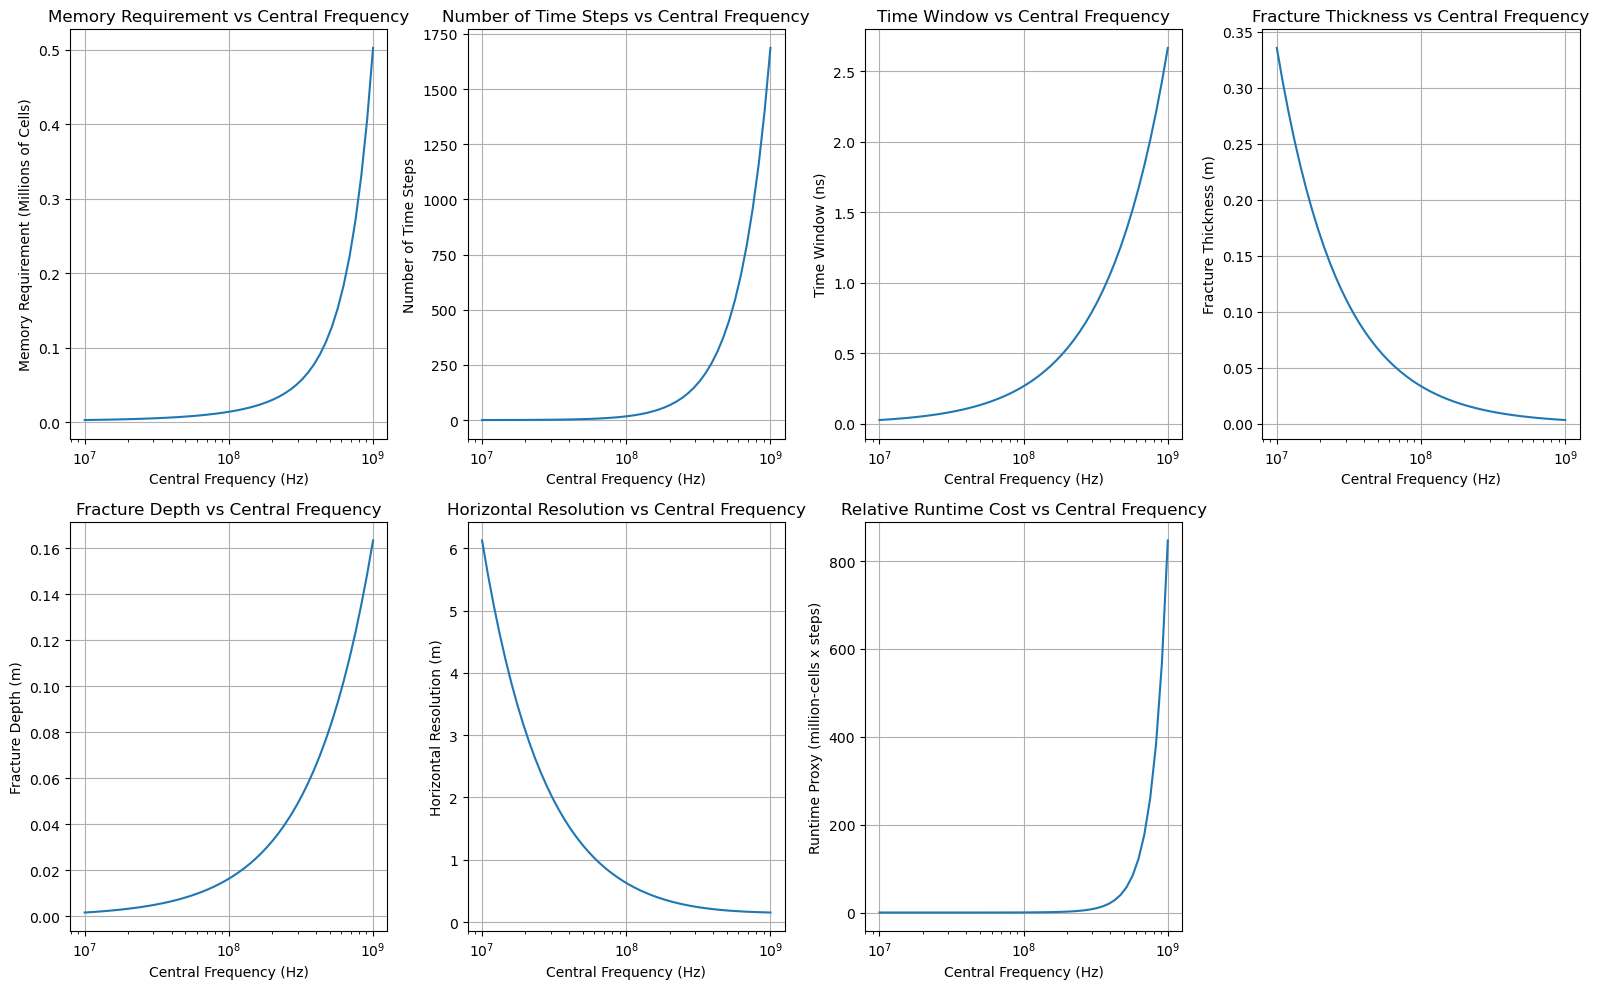

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

axes[0, 0].plot(f_central, memory)
axes[0, 0].set_xlabel('Central Frequency (Hz)')
axes[0, 0].set_ylabel('Memory Requirement (Millions of Cells)')
axes[0, 0].set_title('Memory Requirement vs Central Frequency')
axes[0, 0].set_xscale('log')
axes[0, 0].grid()

axes[0, 1].plot(f_central, n_steps)
axes[0, 1].set_xlabel('Central Frequency (Hz)')
axes[0, 1].set_ylabel('Number of Time Steps')
axes[0, 1].set_title('Number of Time Steps vs Central Frequency')
axes[0, 1].set_xscale('log')
axes[0, 1].grid()

axes[0, 2].plot(f_central, TW)
axes[0, 2].set_xlabel('Central Frequency (Hz)')
axes[0, 2].set_ylabel('Time Window (ns)')
axes[0, 2].set_title('Time Window vs Central Frequency')
axes[0, 2].set_xscale('log')
axes[0, 2].grid()

axes[0, 3].plot(f_central, thickness)
axes[0, 3].set_xlabel('Central Frequency (Hz)')
axes[0, 3].set_ylabel('Fracture Thickness (m)')
axes[0, 3].set_title('Fracture Thickness vs Central Frequency')
axes[0, 3].set_xscale('log')
axes[0, 3].grid()

axes[1, 0].plot(f_central, depth)
axes[1, 0].set_xlabel('Central Frequency (Hz)')
axes[1, 0].set_ylabel('Fracture Depth (m)')
axes[1, 0].set_title('Fracture Depth vs Central Frequency')
axes[1, 0].set_xscale('log')
axes[1, 0].grid()

axes[1, 1].plot(f_central, dH)
axes[1, 1].set_xlabel('Central Frequency (Hz)')
axes[1, 1].set_ylabel('Horizontal Resolution (m)')
axes[1, 1].set_title('Horizontal Resolution vs Central Frequency')
axes[1, 1].set_xscale('log')
axes[1, 1].grid()

axes[1, 2].plot(f_central, cost)
axes[1, 2].set_xlabel('Central Frequency (Hz)')
axes[1, 2].set_ylabel('Runtime Proxy (million-cells x steps)')
axes[1, 2].set_title('Relative Runtime Cost vs Central Frequency')
axes[1, 2].set_xscale('log')
axes[1, 2].grid()

axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


## Constraint-based optimisation
Set memory and runtime limits, then pick the lowest-cost feasible setup. Tune the limits to match your hardware and turnaround target.

Feasible designs: 4 / 50
Recommended setup:
  f_central = 1.389e+08 Hz
  memory    = 0.020 million cells
  n_steps   = 3.256e+01
  cost      = 6.384e-01
  thickness = 0.0241 m
  depth     = 0.023 m
  dx=dy=dz  = 0.00241 m

Top physics+memory-feasible candidates (best to worst):
  f=1.39e+08 Hz | mem=0.020 M | n_steps=32.6 | thickness=0.0241 m | cost=6.38e-01
  f=1.53e+08 Hz | mem=0.022 M | n_steps=39.3 | thickness=0.0220 m | cost=8.55e-01
  f=1.26e+08 Hz | mem=0.018 M | n_steps=27.0 | thickness=0.0265 m | cost=4.78e-01
  f=1.68e+08 Hz | mem=0.024 M | n_steps=47.4 | thickness=0.0200 m | cost=1.15e+00


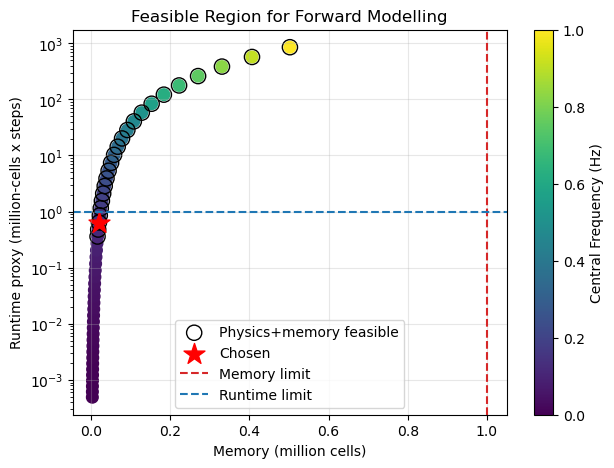

In [12]:
# User-defined limits (adjust for your machine and physics target).
max_memory_million_cells = 1.0
max_runtime_proxy = np.percentile(cost, 60)
max_resolved_fracture_thickness_m = 0.03  # Require <= 3 cm fracture thickness.


base_feasible = (
    (memory <= max_memory_million_cells)
    & (thickness <= max_resolved_fracture_thickness_m)
)
feasible = base_feasible & (cost <= max_runtime_proxy)

print(f'Feasible designs: {np.count_nonzero(feasible)} / {len(f_central)}')

if np.any(base_feasible):
    # Weighted objective on normalized terms.
    memory_norm = memory / np.max(memory)
    cost_norm = cost / np.max(cost)
    thickness_norm = thickness / np.max(thickness)
    objective = 0.30 * memory_norm + 0.50 * cost_norm + 0.20 * thickness_norm

    if np.any(feasible):
        objective_feasible = np.where(feasible, objective, np.inf)
        best_idx = int(np.argmin(objective_feasible))
        fallback_used = False
    else:
        # Runtime constraint is too strict: choose best memory+physics-feasible design.
        objective_base = np.where(base_feasible, objective, np.inf)
        best_idx = int(np.argmin(objective_base))
        fallback_used = True

    print('Recommended setup:')
    print(f'  f_central = {f_central[best_idx]:.3e} Hz')
    print(f'  memory    = {memory[best_idx]:.3f} million cells')
    print(f'  n_steps   = {n_steps[best_idx]:.3e}')
    print(f'  cost      = {cost[best_idx]:.3e}')
    print(f'  thickness = {thickness[best_idx]:.4f} m')
    print(f'  depth     = {depth[best_idx]:.3f} m')
    print(f'  dx=dy=dz  = {dx_dy_dz[best_idx]:.5f} m')

    if fallback_used:
        print('\nCurrent runtime limit is too strict for the physics target.')
        print(f'Minimum runtime_proxy needed: {cost[best_idx]:.3e}')

    # Show top candidates so you can choose a better balance if needed.
    candidate_ids = np.where(base_feasible)[0]
    ranked = candidate_ids[np.argsort(objective[candidate_ids])]
    print('\nTop physics+memory-feasible candidates (best to worst):')
    for i in ranked[:4]:
        print(
            f'  f={f_central[i]:.2e} Hz | mem={memory[i]:.3f} M | '
            f'n_steps={n_steps[i]:.1f} | thickness={thickness[i]:.4f} m | cost={cost[i]:.2e}'
        )
else:
    print('No design satisfies memory + thickness constraints. Reduce model extent or relax thickness target.')

plt.figure(figsize=(7, 5))
plt.scatter(memory, cost, c=f_central, cmap='viridis', s=70)
if np.any(base_feasible):
    plt.scatter(memory[base_feasible], cost[base_feasible], facecolors='none', edgecolors='black', s=120, label='Physics+memory feasible')
    plt.scatter(memory[best_idx], cost[best_idx], marker='*', s=250, c='red', label='Chosen')
plt.axvline(max_memory_million_cells, color='tab:red', linestyle='--', label='Memory limit')
plt.axhline(max_runtime_proxy, color='tab:blue', linestyle='--', label='Runtime limit')
cbar = plt.colorbar()
cbar.set_label('Central Frequency (Hz)')
plt.yscale('log')
plt.xlabel('Memory (million cells)')
plt.ylabel('Runtime proxy (million-cells x steps)')
plt.title('Feasible Region for Forward Modelling')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Other method: fixing thickness and depth

In [170]:
f_central = 1.5 * 1e9 # 1.5 GHz

wavelength_ice   = c_ice   / f_central
wavelength_air   = c_air   / f_central
wavelength_water = c_water / f_central

source_receiver_spacing = 0.10 # 10 cm

In [171]:
depth_fracture = 0.30 # fracture_depth(source_receiver_spacing, wavelength_ice)
thickness = wavelength_water / 10 # fracture_thickness(wavelength_water)
dx_dy_dz = discretisation(thickness)
dH = horizontal_resolution(wavelength_ice, depth_fracture)
TW_ns = time_window(f_central, depth_fracture, c_ice)
TW = TW_ns * 1e-9 # seconds for gprMax input
# n_steps = compute_number_of_time_steps(dx_dy_dz, c_ice, TW_ns)
# memory = number_of_cells(domain_height(thickness, depth_fracture), domain_width(dH), dx_dy_dz)
# cost = runtime_proxy(memory, n_steps)

print(f'For f_central = {f_central:.2e} Hz:')
print(f'  Fracture depth: {depth_fracture:.2f} m')
print(f'  Fracture thickness: {thickness:.3f} m')
print(f'  Discretisation: {dx_dy_dz:.4f} m')
print(f'  Horizontal resolution: {dH:.2f} m')
print(f'  Time window: {TW_ns:.2e} ns ({TW:.2e} s)')

For f_central = 1.50e+09 Hz:
  Fracture depth: 0.30 m
  Fracture thickness: 0.002 m
  Discretisation: 0.0002 m
  Horizontal resolution: 0.16 m
  Time window: 6.90e+00 ns (6.90e-09 s)


In [183]:
optimise_factor_1 = 0.1
optimise_factor_2 = 0.05 # m
optimise_factor_3 = 0.05 # m

# Half-width must be at least dH; optimise_factor_1 adds extra safety margin.
w1 = dH * (1 + optimise_factor_1)
w2 = 2 * w1

t1 = optimise_factor_2
t2 = thickness       # fixed, m
t3 = depth_fracture  # fixed, m
t4 = optimise_factor_3

h1 = t1
h2 = t1 + t2
h3 = t1 + t2 + t3
h4 = t1 + t2 + t3 + t4

nx = int(np.ceil(w2 / dx_dy_dz)) + 1
ny = int(np.ceil(h4 / dx_dy_dz)) + 1
estimated_cells = nx * ny

print(f'The extent of the domain is approximately {h4:.2f} m, with the fracture located at {h3-h2:.2f} m depth and a thickness of {t2:.3f} m.')
print(f'Width control: dH={dH:.3f} m, optimise_factor_1={optimise_factor_1:.3f}, half-width w1={w1:.3f} m, full width w2={w2:.3f} m')
print(f'Estimated grid: nx={nx}, ny={ny}, total cells~{estimated_cells:,}')

The extent of the domain is approximately 0.40 m, with the fracture located at 0.30 m depth and a thickness of 0.002 m.
Width control: dH=0.162 m, optimise_factor_1=0.100, half-width w1=0.178 m, full width w2=0.356 m
Estimated grid: nx=1593, ny=1800, total cells~2,867,400


In [184]:
snapshot_time = TW / 10
snapshot_time

np.float64(6.898979485566356e-10)

In [185]:
with open('trial.in', "w") as f:
    f.write("#title: Subwavelength Fracture")
    f.write("\n#domain: {} {} {}".format(w2, h4, dx_dy_dz))
    f.write("\n#dx_dy_dz: {} {} {}".format(dx_dy_dz, dx_dy_dz, dx_dy_dz))
    f.write("\n#time_window: {}".format(TW))

    f.write("\n#material: 6.0 0.01 1 0 ice")
    f.write("\n#material: 1 0 1 0 air")
    f.write("\n#material: 80 0.05 1 0 fracture")

    f.write("\n#waveform: ricker 1 {} my_ricker".format(f_central))
    f.write("\n#hertzian_dipole: z {} {} 0 my_ricker".format(w1, h3))
    f.write("\n#rx: {} {} 0".format(w1 + 1 * source_receiver_spacing, h3))

    f.write("\n#box: 0 {} 0 {} {} {} air".format(h3, w2, h4, dx_dy_dz))
    f.write("\n#box: 0 0 0 {} {} {} ice".format(w2, h3, dx_dy_dz))
    f.write("\n#box: 0 {} 0 {} {} {} fracture".format(h1, w2, h2, dx_dy_dz))

    f.write("\n#python:")
    f.write("\nfor i in range(1, 11):")
    f.write(
        "\n    print('#snapshot: 0 0 0 {} {} {} {} {} {} {{}} snapshot{{}}'.format(i*{}, i))".format(
            w2, h4, dx_dy_dz, dx_dy_dz, dx_dy_dz, dx_dy_dz, snapshot_time
        )
    )
    f.write("\n#end_python:")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25548\2654027811.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=16)


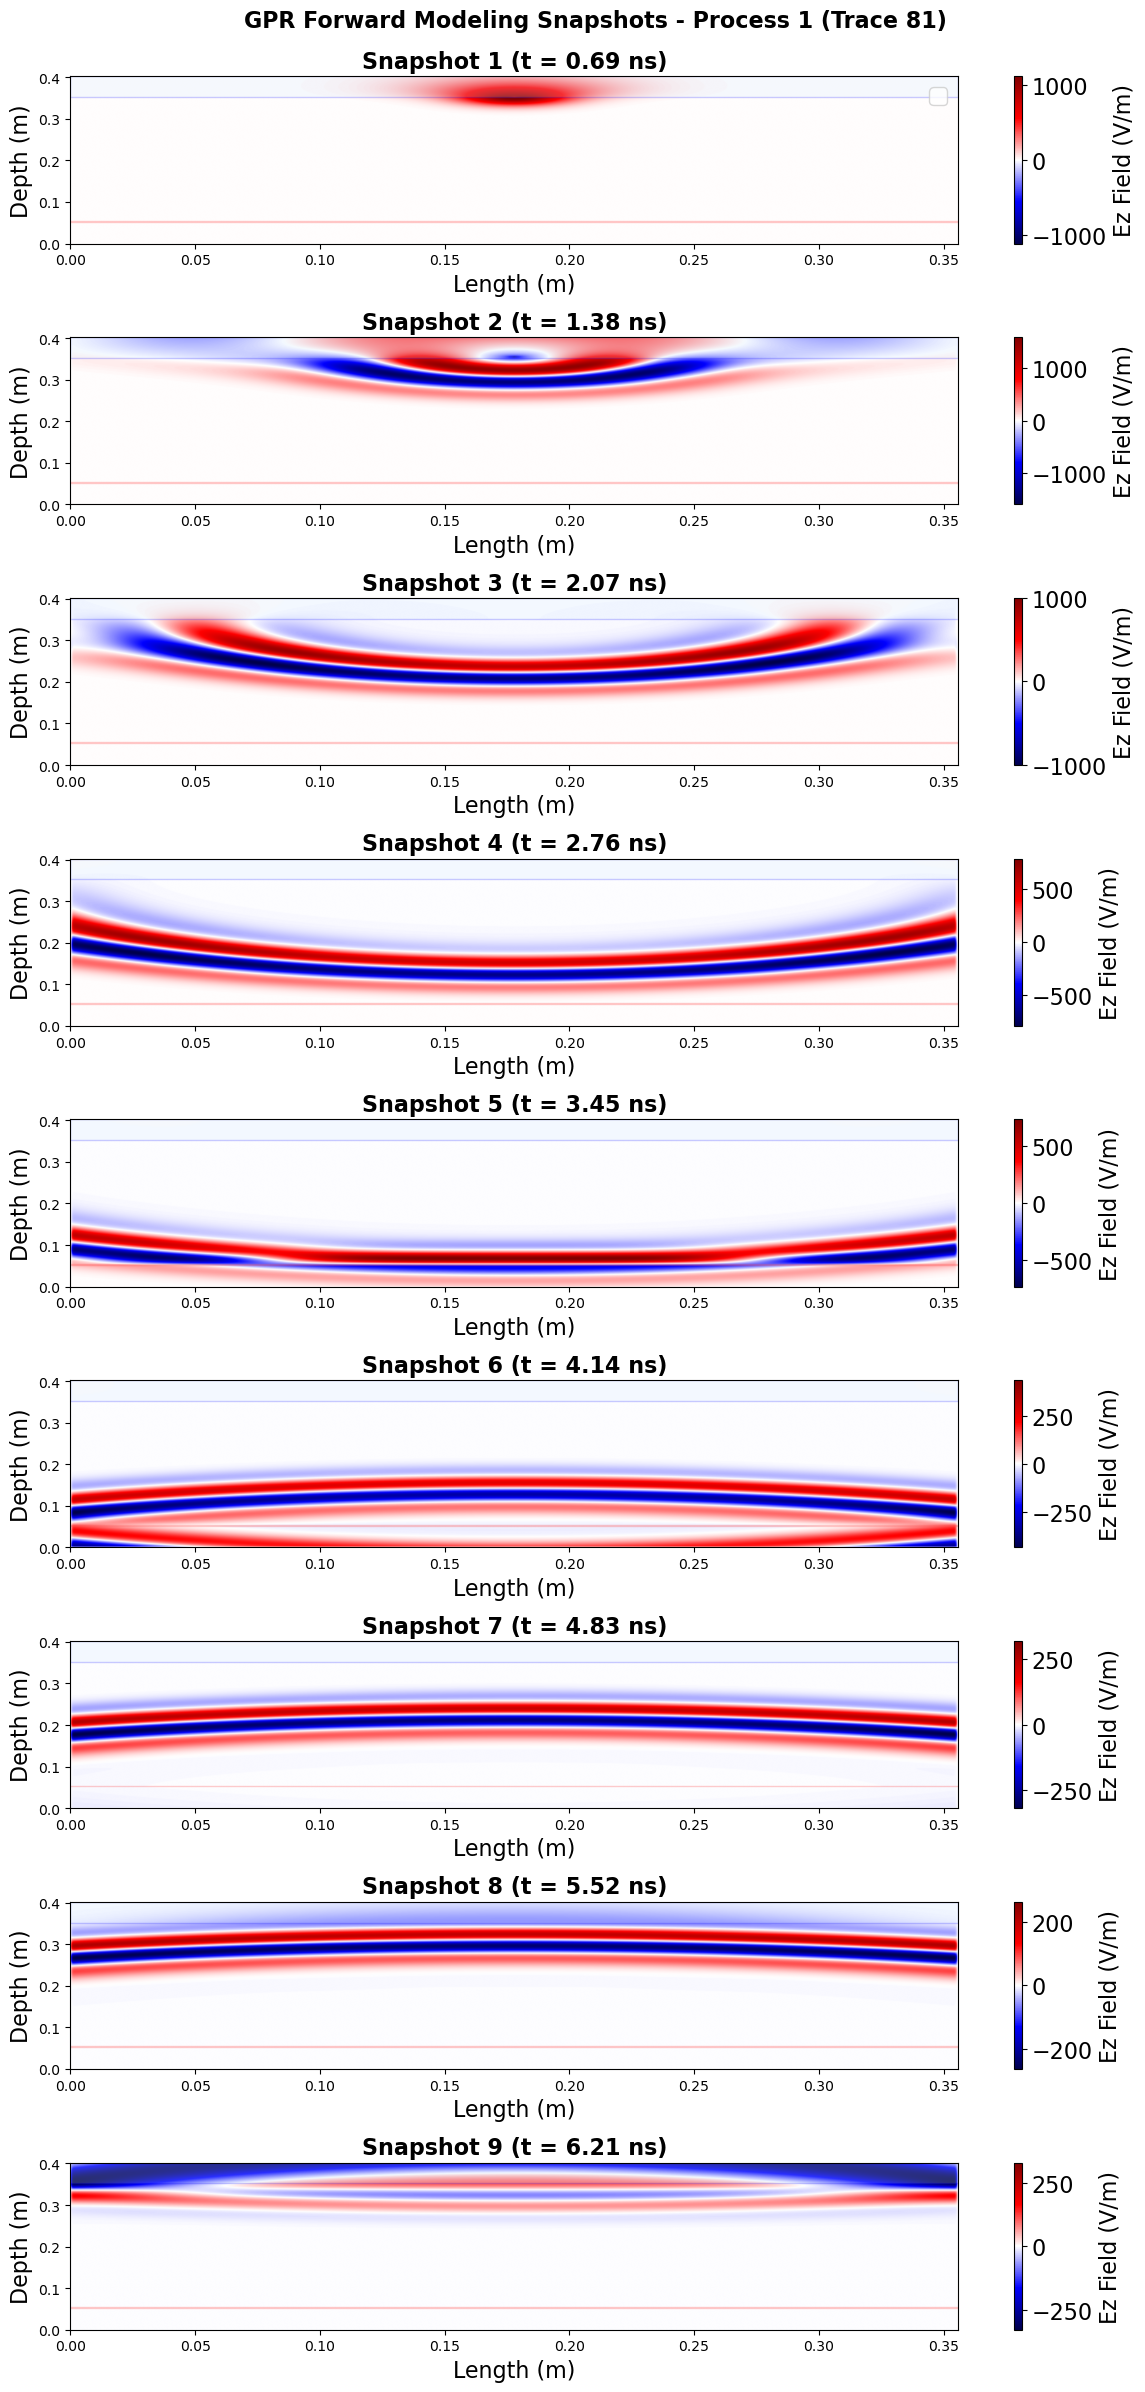

In [ ]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Model dimensions
model_length = w2   # x-length (m)
model_depth  = h4   # y-depth (m)
upper_layer_thickness = t4  # m

# Path to snapshot folder
snapshot_folder = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\EMCEE\My_Scripts\trial_snaps'

# Select 8 evenly spaced snapshots from the 100 available
snapshot_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Create a figure with 8 subplots arranged vertically
fig, axes = plt.subplots(9, 1, figsize=(12, 24))

for i, (ax, snap_num) in enumerate(zip(axes, snapshot_indices)):
    # Read the VTI file
    snapshot_path = f'{snapshot_folder}\\snapshot{snap_num}.vti'
    mesh = pv.read(snapshot_path)
    
    # Get the mesh dimensions
    dims = mesh.dimensions
    
    # Check available field names
    field_name = 'E-field'  # This is a vector field with 3 components (Ex, Ey, Ez)
    
    if field_name in mesh.array_names:
        data = mesh[field_name]
        
        # E-field is a 3-component vector field
        # Reshape to get the grid: (nx-1) * (ny-1) * (nz-1) points, each with 3 components
        num_cells = (dims[0]-1) * (dims[1]-1) * (dims[2]-1)
        
        # Extract Ez component (index 2)
        if data.shape[1] == 3:  # Vector field with 3 components
            Ez_data = data[:, 2]  # Get z-component
        else:
            Ez_data = data.flatten()
        
        # Reshape to 2D grid (for 2D simulation, z-dimension is 1)
        data_2d = Ez_data.reshape(dims[1]-1, dims[0]-1)
        
        # Plot the data (without transpose)
        im = ax.imshow(data_2d, aspect='auto', cmap='seismic', origin='lower',
                      vmin=-np.abs(data_2d).max(), vmax=np.abs(data_2d).max(),
                      extent=[0, model_length, 0, model_depth])
        
        # Calculate time for this snapshot
        time_ns = snap_num * snapshot_time * 1e9
        
        ax.set_title(f'Snapshot {snap_num} (t = {time_ns:.2f} ns)', fontsize=16, weight='bold')
        ax.set_xlabel('Length (m)', fontsize=16)
        ax.set_ylabel('Depth (m)', fontsize=16)
        
        # Upper layer (top)
        ax.add_patch(Rectangle((0, model_depth - upper_layer_thickness), model_length, upper_layer_thickness,
                               facecolor='#cfe8ff', edgecolor='blue', alpha=0.2))

        # Fracture layer
        ax.add_patch(Rectangle((0, h2), model_length, t2,
                               facecolor='#ffcccc', edgecolor='red', alpha=0.2))
        
        # Add legend to first subplot only
        if i == 0:
            ax.legend(loc='upper right', fontsize=16)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Ez Field (V/m)')
        cbar.ax.tick_params(labelsize=16)
        cbar.set_label('Ez Field (V/m)', fontsize=16)
        
    else:
        ax.text(0.5, 0.5, f'Field {field_name} not found\nAvailable: {mesh.array_names}',
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('GPR Forward Modeling Snapshots', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()

plt.show()

In [189]:
import h5py
hf2 = h5py.File('C:\\Users\\Administrator\\Thesis\\True_and_Baseline_Models\\EMCEE\\My_Scripts\\trial.out', 'r', libver='latest', swmr=True)
Ascan = hf2['rxs/rx1/Ez'][:]
hf2.close()

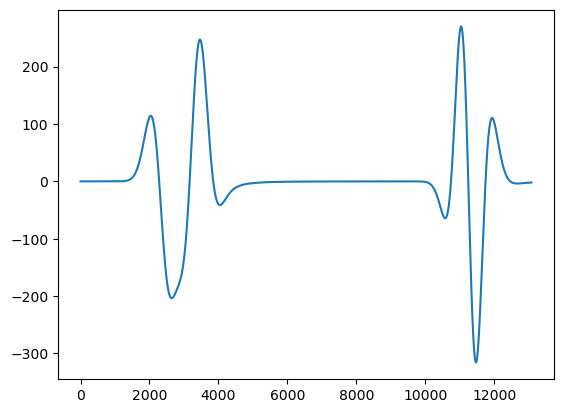

In [190]:
plt.plot(Ascan)

In [194]:
# Benchmark configuration for optimisation-factor sensitivity.
factor1_values = [0.10, 0.25, 0.50]  # width safety factor
factor2_values = [0.05, 0.10, 0.15]  # top margin (m)
factor3_values = [0.05, 0.10, 0.15]  # bottom margin (m)

# Use one-at-a-time sweeps to isolate effect of each factor.
# Options: 'one_at_a_time' or 'full_grid'
sweep_mode = 'one_at_a_time'

# Baseline point used for one-at-a-time sweeps.
baseline_f1 = 0.25
baseline_f2 = 0.10
baseline_f3 = 0.10

# Path to trusted reference output (.out) for A-scan comparison.
# If this file does not exist, the first successful run in this benchmark is used as reference.
reference_out_path = 'reference.out'

# gprMax runner settings.
# CPU mode is more stable for repeated benchmark loops in notebook subprocesses.
use_gpu = False
gpu_id = 0
n_models = 1

# Output control for benchmark files.
benchmark_prefix = 'bench_opt'

## Optimisation-factor sensitivity benchmark
This section measures runtime and A-scan similarity versus a trusted reference trace.

In [ ]:
import itertools
import subprocess
import sys
import time
from pathlib import Path

import h5py
import pandas as pd

def _build_cases(mode, f1_vals, f2_vals, f3_vals, b1, b2, b3):
    if mode == 'full_grid':
        return list(itertools.product(f1_vals, f2_vals, f3_vals))

    cases = []
    for f1 in f1_vals:
        cases.append((f1, b2, b3))
    for f2 in f2_vals:
        cases.append((b1, f2, b3))
    for f3 in f3_vals:
        cases.append((b1, b2, f3))

    # Remove duplicates while keeping order.
    seen = set()
    unique_cases = []
    for c in cases:
        if c not in seen:
            seen.add(c)
            unique_cases.append(c)
    return unique_cases

def _write_in_file(path_in, f_central_hz, dx, h1, h2, h3, h4, w1, w2, tw_s, src_rx_spacing):
    with open(path_in, 'w') as f:
        f.write('#title: Subwavelength Fracture Benchmark')
        f.write('\n#domain: {} {} {}'.format(w2, h4, dx))
        f.write('\n#dx_dy_dz: {} {} {}'.format(dx, dx, dx))
        f.write('\n#time_window: {}'.format(tw_s))

        f.write('\n#material: 6.0 0.01 1 0 ice')
        f.write('\n#material: 1 0 1 0 air')
        f.write('\n#material: 80 0.05 1 0 fracture')

        f.write('\n#waveform: ricker 1 {} my_ricker'.format(f_central_hz))
        f.write('\n#hertzian_dipole: z {} {} 0 my_ricker'.format(w1, h3))
        f.write('\n#rx: {} {} 0'.format(w1 + src_rx_spacing, h3))

        f.write('\n#box: 0 {} 0 {} {} {} air'.format(h3, w2, h4, dx))
        f.write('\n#box: 0 0 0 {} {} {} ice'.format(w2, h3, dx))
        f.write('\n#box: 0 {} 0 {} {} {} fracture'.format(h1, w2, h2, dx))

def _read_ascan(out_path):
    with h5py.File(out_path, 'r', libver='latest', swmr=True) as hf:
        return hf['rxs/rx1/Ez'][:]

def _trace_metrics(trace, ref):
    n = min(len(trace), len(ref))
    t = trace[:n]
    r = ref[:n]

    # Normalize for robust shape comparison independent of amplitude scaling.
    t0 = t - np.mean(t)
    r0 = r - np.mean(r)

    eps = 1e-12
    nrmse = np.sqrt(np.mean((t - r) ** 2)) / (np.std(r) + eps)
    corr = np.corrcoef(t0, r0)[0, 1] if np.std(t0) > 0 and np.std(r0) > 0 else 0.0

    xcorr = np.correlate(t0, r0, mode='full')
    lag = int(np.argmax(xcorr) - (n - 1))

    return nrmse, corr, lag

def _run_case(in_path, n_models, use_gpu_flag, gpu_index):
    cmd = [sys.executable, '-m', 'gprMax', str(in_path), '-n', str(n_models)]
    if use_gpu_flag:
        cmd += ['-gpu', str(gpu_index)]

    t0 = time.perf_counter()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    return proc, elapsed, cmd

# Build benchmark directory and case list.
bench_dir = Path.cwd() / 'benchmark_runs'
bench_dir.mkdir(exist_ok=True)

cases = _build_cases(
    sweep_mode,
    factor1_values, factor2_values, factor3_values,
    baseline_f1, baseline_f2, baseline_f3,
)
print(f'Planned cases: {len(cases)}')

# Reference trace setup.
ref_path = Path(reference_out_path)
reference_trace = None
if ref_path.exists():
    reference_trace = _read_ascan(ref_path)
    print(f'Using explicit reference trace: {ref_path}')
else:
    print('Reference file not found; first successful case will be used as reference.')

rows = []
for i, (f1, f2, f3) in enumerate(cases, start=1):
    # Geometry from current physical setup variables in the notebook.
    w1_case = dH * (1 + f1)
    w2_case = 2 * w1_case

    t1_case = f2
    t2_case = thickness
    t3_case = depth_fracture
    t4_case = f3

    h1_case = t1_case
    h2_case = t1_case + t2_case
    h3_case = t1_case + t2_case + t3_case
    h4_case = t1_case + t2_case + t3_case + t4_case

    nx_case = int(np.ceil(w2_case / dx_dy_dz)) + 1
    ny_case = int(np.ceil(h4_case / dx_dy_dz)) + 1
    est_cells_case = nx_case * ny_case

    in_path = bench_dir / f'{benchmark_prefix}_{i:03d}.in'
    out_path = bench_dir / f'{benchmark_prefix}_{i:03d}.out'

    _write_in_file(
        in_path,
        f_central,
        dx_dy_dz,
        h1_case, h2_case, h3_case, h4_case,
        w1_case, w2_case,
        TW,
        source_receiver_spacing,
    )

    proc, elapsed, cmd = _run_case(in_path, n_models, use_gpu, gpu_id)
    run_mode = 'gpu' if use_gpu else 'cpu'

    # Known notebook+PyCUDA issue in repeated subprocess loops: fallback to CPU automatically.
    if proc.returncode != 0 and use_gpu and 'PyCUDA ERROR' in proc.stderr:
        proc, elapsed_cpu, cmd = _run_case(in_path, n_models, False, gpu_id)
        elapsed += elapsed_cpu
        run_mode = 'cpu_fallback'

    if proc.returncode != 0 or not out_path.exists():
        rows.append({
            'case': i,
            'f1': f1, 'f2': f2, 'f3': f3,
            'width_m': w2_case, 'height_m': h4_case,
            'nx': nx_case, 'ny': ny_case, 'estimated_cells': est_cells_case,
            'runtime_s': elapsed, 'run_mode': run_mode,
            'status': 'failed',
            'stderr_tail': '\n'.join(proc.stderr.splitlines()[-8:]),
            'nrmse': np.nan, 'corr': np.nan, 'lag_samples': np.nan,
        })
        print(f'Case {i}/{len(cases)} failed (f1={f1}, f2={f2}, f3={f3}).')
        continue

    trace = _read_ascan(out_path)
    if reference_trace is None:
        reference_trace = trace.copy()
        print(f'Case {i} promoted as reference trace.')

    nrmse, corr, lag = _trace_metrics(trace, reference_trace)

    rows.append({
        'case': i,
        'f1': f1, 'f2': f2, 'f3': f3,
        'width_m': w2_case, 'height_m': h4_case,
        'nx': nx_case, 'ny': ny_case, 'estimated_cells': est_cells_case,
        'runtime_s': elapsed, 'run_mode': run_mode,
        'status': 'ok',
        'stderr_tail': '',
        'nrmse': nrmse, 'corr': corr, 'lag_samples': lag,
    })

    print(
        f'Case {i}/{len(cases)} ok ({run_mode}): runtime={elapsed:.2f}s, '
        f'corr={corr:.4f}, nrmse={nrmse:.4f}, lag={lag} samples'
    )

benchmark_df = pd.DataFrame(rows)
display(benchmark_df)

csv_path = bench_dir / f'{benchmark_prefix}_results.csv'
benchmark_df.to_csv(csv_path, index=False)
print(f'Results saved: {csv_path}')

Planned cases: 7
Reference file not found; first successful case will be used as reference.
Case 1 promoted as reference trace.
Case 1/7 ok (cpu): runtime=166.44s, corr=1.0000, nrmse=0.0000, lag=0 samples
Case 2/7 ok (cpu): runtime=191.74s, corr=1.0000, nrmse=0.0015, lag=0 samples
Case 3/7 ok (cpu): runtime=234.21s, corr=1.0000, nrmse=0.0010, lag=0 samples
Case 4/7 ok (cpu): runtime=170.67s, corr=0.9995, nrmse=0.0314, lag=-5 samples
Case 5/7 ok (cpu): runtime=218.31s, corr=0.9995, nrmse=0.0314, lag=-5 samples
Case 6/7 ok (cpu): runtime=176.25s, corr=1.0000, nrmse=0.0041, lag=0 samples


In [1]:
ok_df = benchmark_df[benchmark_df['status'] == 'ok'].copy()
if ok_df.empty:
    print('No successful runs to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].scatter(ok_df['width_m'], ok_df['runtime_s'])
    axes[0].set_xlabel('Model width (m)')
    axes[0].set_ylabel('Runtime (s)')
    axes[0].set_title('Runtime vs Width')
    axes[0].grid(alpha=0.3)

    axes[1].scatter(ok_df['runtime_s'], ok_df['corr'])
    axes[1].set_xlabel('Runtime (s)')
    axes[1].set_ylabel('Correlation to Reference')
    axes[1].set_title('Fidelity vs Runtime')
    axes[1].grid(alpha=0.3)

    axes[2].scatter(ok_df['runtime_s'], ok_df['nrmse'])
    axes[2].set_xlabel('Runtime (s)')
    axes[2].set_ylabel('NRMSE to Reference')
    axes[2].set_title('Error vs Runtime')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show best speed/fidelity tradeoffs.
    print('Top 5 fastest successful cases:')
    display(ok_df.sort_values('runtime_s').head(5))

    print('Top 5 highest-correlation successful cases:')
    display(ok_df.sort_values('corr', ascending=False).head(5))

NameError: name 'benchmark_df' is not defined